In [1]:
import pandas as pd
import numpy as np
import os
import glob

# 1. DANH SÁCH ĐẶC TRƯNG (Giữ nguyên 25 đặc trưng xịn)
SELECTED_FEATURES = [
    'IAT', 'syn_flag_number', 'psh_flag_number', 'fin_flag_number', 
    'rst_flag_number', 'ack_flag_number', 'Tot sum', 'Protocol Type', 
    'flow_duration', 'Rate', 'Std', 'Variance', 'UDP', 'TCP', 'HTTP', 
    'HTTPS', 'DNS', 'Duration', 'Number', 'ICMP', 'Magnitue', 
    'Header_Length', 'AVG', 'Min', 'Max'
]

# 2. CẤU HÌNH ĐƯỜNG DẪN
INPUT_DIR = '/kaggle/input/datasets/nguyenleanhtuan07/b-data-scale-encoding-v-chia-theo-tng-label/' 
LABEL_MAP_PATH = '/kaggle/input/datasets/nguyenleanhtuan07/nhn-34/label_map_key.csv'
OUTPUT_DATA = '/kaggle/working/layer2_mirai_3labels_data.csv.gz'
SAMPLES_PER_FILE = 100000 # Số lượng mẫu tối đa cho mỗi file

# 3. DANH SÁCH 3 NHÃN MIRAI CHI TIẾT
TARGET_MIRAI_LABELS = [
    'Mirai-greip_flood', 
    'Mirai-greeth_flood', 
    'Mirai-udpplain'
]

def basic_clean(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()
    return df

def process_layer2_mirai():
    label_lookup = pd.read_csv(LABEL_MAP_PATH)
    first_write = True
    
    csv_files = glob.glob(os.path.join(INPUT_DIR, "*.csv"))
    print(f"Bắt đầu quy trình trích xuất Mirai (3 nhãn chi tiết) trên {len(csv_files)} file...")

    # Khởi tạo bộ đếm cho 3 nhãn
    group_counts = {label: 0 for label in TARGET_MIRAI_LABELS}

    for file_path in csv_files:
        # Đọc nhãn từ file
        temp_df = pd.read_csv(file_path, nrows=1)
        if 'label' not in temp_df.columns: continue
        label_id = temp_df['label'].iloc[0]
        
        # Tìm tên nhãn gốc
        match = label_lookup[label_lookup['Encoded_ID'] == label_id]
        if match.empty: continue
        original_name = match['Original_Label'].values[0]
        
        # LỌC: Chỉ xử lý nếu nhãn nằm trong danh sách 3 loại Mirai
        if original_name not in TARGET_MIRAI_LABELS:
            continue
            
        # Đọc dữ liệu với các cột đã chọn
        available_cols = pd.read_csv(file_path, nrows=0).columns.tolist()
        use_cols = [c for c in SELECTED_FEATURES if c in available_cols]
        df_full = pd.read_csv(file_path, usecols=use_cols)
        
        # Dọn dẹp dữ liệu
        df_cleaned = basic_clean(df_full)
        if len(df_cleaned) == 0: continue
        
        # Lấy mẫu ngẫu nhiên
        num_sample = min(len(df_cleaned), SAMPLES_PER_FILE)
        df_sampled = df_cleaned.sample(n=num_sample, random_state=42)
        
        # Gán nhãn trực tiếp bằng tên chủng loại (GIỮ NGUYÊN CHỮ)
        df_sampled['layer2_label'] = original_name
        group_counts[original_name] += num_sample
        
        # Ghi file (nối tiếp nếu đã có dữ liệu)
        if first_write:
            df_sampled.to_csv(OUTPUT_DATA, index=False, compression='gzip')
            first_write = False
        else:
            df_sampled.to_csv(OUTPUT_DATA, mode='a', index=False, header=False, compression='gzip')
            
        print(f"Đã trích xuất: {original_name} -> {num_sample} dòng")
        del df_full, df_cleaned, df_sampled

    print("\n--- TỔNG KẾT DỮ LIỆU MIRAI (3 NHÃN) ---")
    for label, count in group_counts.items():
        if count > 0:
            print(f"{label}: {count} dòng")
    print(f"\nFile đã được lưu tại: {OUTPUT_DATA}")
    print("--- HOÀN TẤT ---")

if __name__ == "__main__":
    process_layer2_mirai()

Bắt đầu quy trình trích xuất Mirai (3 nhãn chi tiết) trên 34 file...
Đã trích xuất: Mirai-greeth_flood -> 100000 dòng
Đã trích xuất: Mirai-greip_flood -> 100000 dòng
Đã trích xuất: Mirai-udpplain -> 100000 dòng

--- TỔNG KẾT DỮ LIỆU MIRAI (3 NHÃN) ---
Mirai-greip_flood: 100000 dòng
Mirai-greeth_flood: 100000 dòng
Mirai-udpplain: 100000 dòng

File đã được lưu tại: /kaggle/working/layer2_mirai_3labels_data.csv.gz
--- HOÀN TẤT ---


=> Đang tải dữ liệu Mirai (3 nhãn: Greip, Greeth, Upplain)...
Các nhóm Mirai nhận diện: ['Mirai-greeth_flood', 'Mirai-greip_flood', 'Mirai-udpplain']

=> Bắt đầu huấn luyện và đánh giá 5-Fold CV cho họ DoS...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[145]	valid_0's multi_logloss: 0.000874314
   + Hoàn thành Fold 1
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[146]	valid_0's multi_logloss: 0.000922531
   + Hoàn thành Fold 2
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[160]	valid_0's multi_logloss: 0.000672771
   + Hoàn thành Fold 3
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[144]	valid_0's multi_logloss: 0.000997921
   + Hoàn thành Fold 4
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[147]	valid_0's multi_logloss: 0.000803902
   +

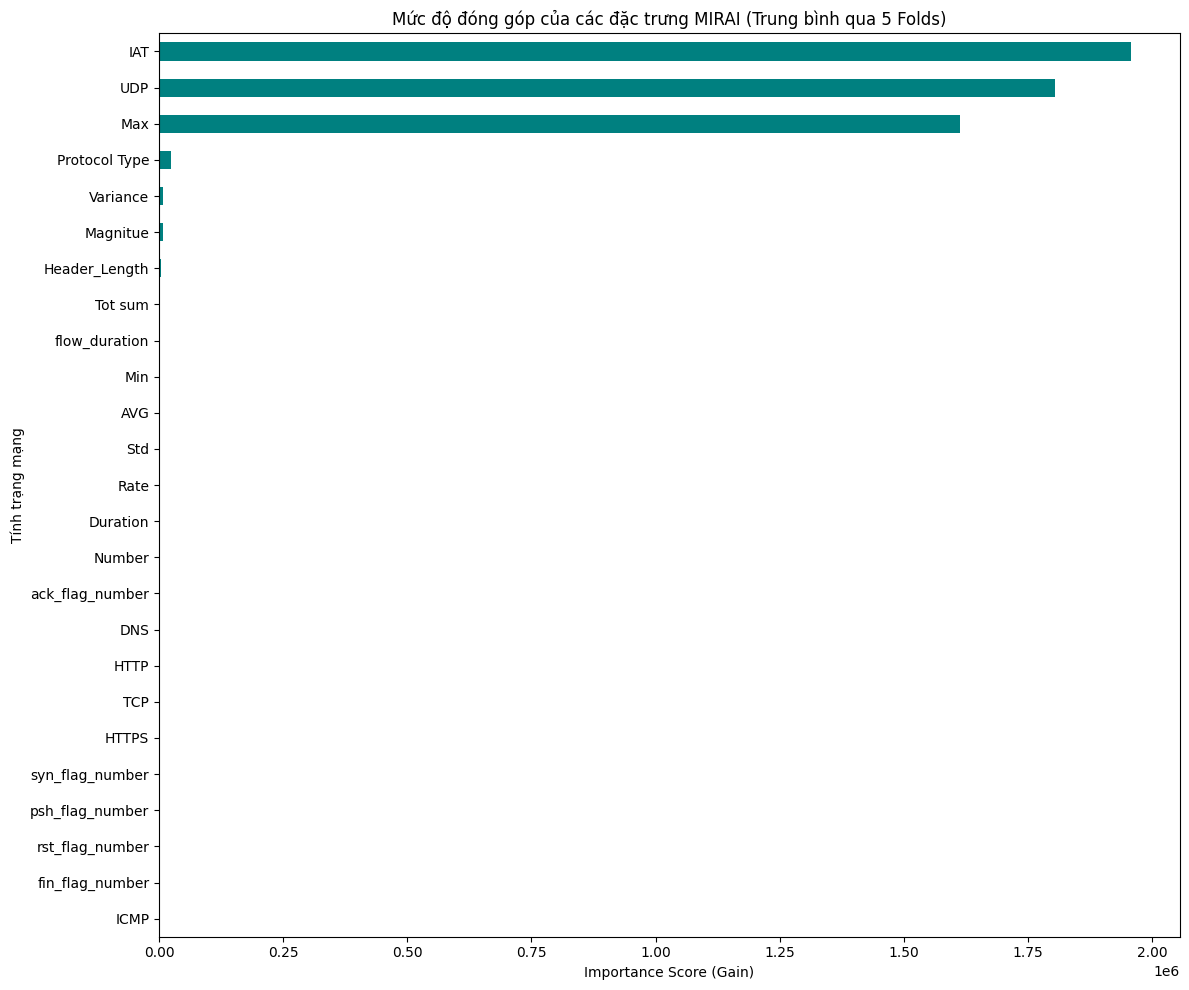

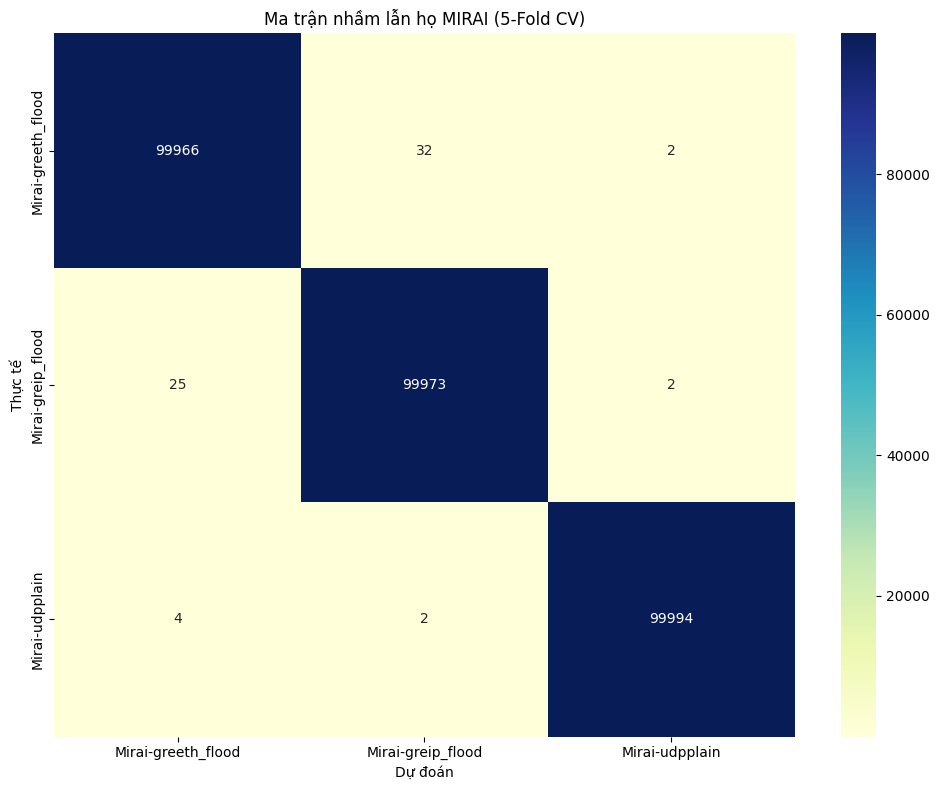

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# --- 1. CẤU HÌNH ---
# Trỏ đúng vào file DoS đã xuất nhãn chữ hoặc nhãn số
INPUT_FILE = '/kaggle/working/layer2_mirai_3labels_data.csv.gz'
K_FOLDS = 5

print("=> Đang tải dữ liệu Mirai (3 nhãn: Greip, Greeth, Upplain)...")
df = pd.read_csv(INPUT_FILE)
df.columns = df.columns.str.strip()

# Tách Features và Target (Cột nhãn là 'dos_label' như đã xuất ở bước trước)
target_col = 'mirai_label' if 'mirai_label' in df.columns else df.columns[-1]
X = df.drop(columns=[target_col])
y_raw = df[target_col]

# Chuyển đổi nhãn sang số để LightGBM xử lý
le = LabelEncoder()
y = pd.Series(le.fit_transform(y_raw))
target_names = le.classes_
print(f"Các nhóm Mirai nhận diện: {list(target_names)}")

# --- 2. THIẾT LẬP K-FOLD ---
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

fold_metrics = []
all_latency = []
oof_preds = np.zeros(len(df))
feature_importance_df = pd.DataFrame() 

print(f"\n=> Bắt đầu huấn luyện và đánh giá {K_FOLDS}-Fold CV cho họ DoS...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Cấu hình tham số LightGBM tối ưu cho dữ liệu mạng
    params = {
        'objective': 'multiclass', 
        'num_class': len(target_names),
        'metric': 'multi_logloss', 
        'is_unbalance': True,
        'learning_rate': 0.05, 
        'num_leaves': 63, 
        'max_bin': 255,
        'min_data_in_leaf': 50,
        'device': 'cpu', 
        'verbose': -1, 
        'seed': 42
    }
    
    train_set = lgb.Dataset(X_train, label=y_train)
    val_set = lgb.Dataset(X_val, label=y_val, reference=train_set)
    
    model = lgb.train(
        params, 
        train_set, 
        valid_sets=[val_set], 
        num_boost_round=2000, 
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
    )
    
    # Dự đoán và đo thời gian
    start_pred = time.time()
    y_prob = model.predict(X_val)
    end_pred = time.time()
    
    y_pred = np.argmax(y_prob, axis=1)
    oof_preds[val_idx] = y_pred
    
    # Tính Latency (ms/sample)
    latency_per_sample = (end_pred - start_pred) / len(X_val)
    all_latency.append(latency_per_sample)
    
    # Lưu Feature Importance (Sử dụng Gain để đo mức đóng góp)
    fold_imp = pd.DataFrame({
        'Feature': X.columns, 
        'Importance': model.feature_importance(importance_type='gain')
    })
    feature_importance_df = pd.concat([feature_importance_df, fold_imp], axis=0)
    
    # Lưu chỉ số của Fold
    fold_metrics.append({
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred, average='macro'),
        'recall': recall_score(y_val, y_pred, average='macro'),
        'f1': f1_score(y_val, y_pred, average='macro')
    })
    print(f"   + Hoàn thành Fold {fold+1}")

# --- 3. TỔNG HỢP KẾT QUẢ ---
metrics_df = pd.DataFrame(fold_metrics)
avg_metrics = metrics_df.mean()
std_metrics = metrics_df.std()
avg_latency_ms = np.mean(all_latency) * 1000

print("\n" + "="*50)
print(f"⭐ KẾT QUẢ ĐÁNH GIÁ TRUNG BÌNH ({K_FOLDS}-FOLD) - HỌ MIRAI")
print("-" * 50)
print(f"1. Accuracy:  {avg_metrics['accuracy']:.4f} (±{std_metrics['accuracy']:.4f})")
print(f"2. Precision: {avg_metrics['precision']:.4f} (±{std_metrics['precision']:.4f})")
print(f"3. Recall:    {avg_metrics['recall']:.4f} (±{std_metrics['recall']:.4f})")
print(f"4. F1-Score:  {avg_metrics['f1']:.4f} (±{std_metrics['f1']:.4f})")
print("-" * 50)
print(f"⏱ Tốc độ dự đoán trung bình: {avg_latency_ms:.6f} ms/dòng")
print("="*50)

# Báo cáo chi tiết từng nhãn DoS
print("\nBáo cáo phân loại chi tiết (Out-of-Fold):")
print(classification_report(y, oof_preds, target_names=target_names))

# --- 4. BIỂU ĐỒ TÁC ĐỘNG ĐẶC TRƯNG (FEATURE IMPORTANCE) ---
plt.figure(figsize=(12, 10))
mean_imp = feature_importance_df.groupby('Feature')['Importance'].mean().sort_values(ascending=True)
mean_imp.plot(kind='barh', color='teal')
plt.title(f'Mức độ đóng góp của các đặc trưng MIRAI (Trung bình qua {K_FOLDS} Folds)')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Tính trạng mạng')
plt.tight_layout()
plt.savefig('/kaggle/working/dos_feature_importance.png')
plt.show()

# --- 5. MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---
cm = confusion_matrix(y, oof_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Ma trận nhầm lẫn họ MIRAI ({K_FOLDS}-Fold CV)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.tight_layout()
plt.savefig('/kaggle/working/dos_confusion_matrix.png')

In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import pickle
import time
from sklearn.preprocessing import LabelEncoder

# --- 1. CẤU HÌNH ĐẦU VÀO & ĐẦU RA ---
# Sử dụng đúng file Mirai 3 nhãn cậu vừa tạo
INPUT_FILE = '/kaggle/working/layer2_mirai_3labels_data.csv.gz'
MODEL_SAVE_PATH = '/kaggle/working/lightgbm_layer2_mirai_3labels_model.txt'
LABEL_ENCODER_PATH = '/kaggle/working/layer2_mirai_3labels_encoder.pkl' 
META_DATA_PATH = '/kaggle/working/layer2_mirai_3labels_meta.pkl'

print("=> Đang tải dữ liệu Mirai (3 nhãn chi tiết) để huấn luyện...")
df = pd.read_csv(INPUT_FILE)
df.columns = df.columns.str.strip()

# Tách X (Features) và y (Target)
X = df.drop(columns=['layer2_label'])
y_raw = df['layer2_label']

# Mã hóa nhãn chữ sang số (0, 1, 2)
print("=> Đang mã hóa nhãn và lưu LabelEncoder...")
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Lưu LabelEncoder để dùng cho file test/dự đoán sau này
with open(LABEL_ENCODER_PATH, 'wb') as f:
    pickle.dump(le, f)
print(f"   + Đã nhận diện các lớp: {list(le.classes_)}")

# --- 2. THIẾT LẬP THAM SỐ (Giữ nguyên kiến trúc cực mạnh của cậu) ---
params = {
    'objective': 'multiclass',
    'num_class': len(np.unique(y)),
    'metric': 'multi_logloss',
    'is_unbalance': True,       
    'learning_rate': 0.015,      
    'num_leaves': 255,          
    'max_bin': 511,             
    'device': 'cpu',
    'verbose': -1,
    'seed': 42
}

# --- 3. HUẤN LUYỆN TRÊN TOÀN BỘ DỮ LIỆU ---
print(f"\n=> Đang huấn luyện mô hình Mirai trên toàn bộ {len(df):,} dòng dữ liệu...")
start_time = time.time()

# Tạo Dataset cho LightGBM
train_set = lgb.Dataset(X, label=y)

# Huấn luyện mô hình cuối cùng
final_model = lgb.train(
    params, 
    train_set, 
    num_boost_round=2000
)

training_duration = time.time() - start_time
print(f"\n=> Huấn luyện hoàn tất trong {training_duration:.2f} giây.")

# --- 4. LƯU MÔ HÌNH VÀ SIÊU DỮ LIỆU ---
final_model.save_model(MODEL_SAVE_PATH)
print(f"   [+] Đã lưu mô hình tại: {MODEL_SAVE_PATH}")

# Lưu siêu dữ liệu để đảm bảo dự đoán không bị lệch cột
model_info = {
    'features': list(X.columns),
    'num_class': params['num_class']
}
with open(META_DATA_PATH, 'wb') as f:
    pickle.dump(model_info, f)

print("=> HỆ THỐNG TẦNG 2 (MIRAI 3 NHÃN) ĐÃ SẴN SÀNG!")

=> Đang tải dữ liệu Mirai (3 nhãn chi tiết) để huấn luyện...
=> Đang mã hóa nhãn và lưu LabelEncoder...
   + Đã nhận diện các lớp: ['Mirai-greeth_flood', 'Mirai-greip_flood', 'Mirai-udpplain']

=> Đang huấn luyện mô hình Mirai trên toàn bộ 300,000 dòng dữ liệu...

=> Huấn luyện hoàn tất trong 100.81 giây.
   [+] Đã lưu mô hình tại: /kaggle/working/lightgbm_layer2_mirai_3labels_model.txt
=> HỆ THỐNG TẦNG 2 (MIRAI 3 NHÃN) ĐÃ SẴN SÀNG!


In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import pickle
import os
import glob
import random

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN (Khớp với mô hình Mirai 3 nhãn)
# ==========================================
MODEL_PATH = '/kaggle/working/lightgbm_layer2_mirai_3labels_model.txt'
LABEL_ENCODER_PATH = '/kaggle/working/layer2_mirai_3labels_encoder.pkl'
META_DATA_PATH = '/kaggle/working/layer2_mirai_3labels_meta.pkl'

INPUT_DIR = '/kaggle/input/datasets/nguyenleanhtuan07/b-data-scale-encoding-v-chia-theo-tng-label/' 
LABEL_MAP_PATH = '/kaggle/input/datasets/nguyenleanhtuan07/nhn-34/label_map_key.csv'

# Danh sách 3 nhãn Mirai chi tiết để lọc dữ liệu gốc
TARGET_MIRAI_LABELS = [
    'Mirai-greip_flood', 'Mirai-greeth_flood', 'Mirai-udpplain'
]

print("=> Đang khởi động hệ thống AI Mirai 3 nhãn...")
model = lgb.Booster(model_file=MODEL_PATH)
with open(LABEL_ENCODER_PATH, 'rb') as f: le = pickle.load(f)
with open(META_DATA_PATH, 'rb') as f: expected_features = pickle.load(f)['features']

# ==========================================
# 2. SINH TRỌNG SỐ (FEATURE WEIGHTS)
# ==========================================
print("\n" + "="*50)
print("⭐ BƯỚC 1: TRÍCH XUẤT TRỌNG SỐ ĐẶC TRƯNG (MIRAI)")
print("="*50)

# Sử dụng 'gain' để thấy đặc trưng nào đóng góp nhiều nhất
weights = model.feature_importance(importance_type='gain')
weight_df = pd.DataFrame({
    'Feature': expected_features,
    'Weight (Gain)': weights
})

weight_df = weight_df.sort_values(by='Weight (Gain)', ascending=False)
weight_df['Contribution (%)'] = (weight_df['Weight (Gain)'] / weight_df['Weight (Gain)'].sum()) * 100

print(weight_df.head(10).to_string(index=False))
weight_df.to_csv('/kaggle/working/layer2_mirai_3labels_feature_weights.csv', index=False)
print("\n[+] Đã lưu trọng số Mirai ra file: layer2_mirai_3labels_feature_weights.csv")

# ==========================================
# 3. THUẬT TOÁN GOM RỔ DỮ LIỆU ĐẢM BẢO ĐỦ 10 MẪU
# ==========================================
print("\n" + "="*60)
print("🚀 BƯỚC 2: BLIND TEST ĐẢM BẢO ĐỦ 10 MẪU TRÊN DATA GỐC")
print("="*60)

csv_files = glob.glob(os.path.join(INPUT_DIR, "*.csv"))
label_lookup = pd.read_csv(LABEL_MAP_PATH)
label_dict = dict(zip(label_lookup['Encoded_ID'], label_lookup['Original_Label']))

random.shuffle(csv_files) 
sample_pool = []
target_count = 10
samples_per_file = 4 # Tăng số lượng bốc mỗi file lên để "rổ" nhanh đầy

print(f"=> Đang rải lưới quét dữ liệu Mirai Botnet...")

for file_path in csv_files:
    temp_df = pd.read_csv(file_path, nrows=1)
    if 'label' not in temp_df.columns: continue
    
    label_id = temp_df['label'].iloc[0]
    original_name = label_dict.get(label_id, "")
    
    # Lọc đúng 3 nhãn Mirai
    if original_name in TARGET_MIRAI_LABELS:
        available_cols = pd.read_csv(file_path, nrows=0).columns.tolist()
        use_cols = [c for c in expected_features if c in available_cols]
        
        df_raw = pd.read_csv(file_path, usecols=use_cols)
        df_cleaned = df_raw.replace([np.inf, -np.inf], np.nan).dropna()
        
        if len(df_cleaned) > 0:
            # Nhặt tối đa 4 dòng từ file này ném vào rổ
            take_n = min(len(df_cleaned), samples_per_file)
            df_sampled = df_cleaned.sample(n=take_n)
            df_sampled['True_Answer'] = original_name
            sample_pool.append(df_sampled)
            
        # Kiểm tra xem rổ đã có dư dữ liệu chưa
        if sum(len(d) for d in sample_pool) >= target_count * 2:
            break

# ==========================================
# 4. CHỐT SỔ VÀ DỰ ĐOÁN
# ==========================================
if not sample_pool:
    print("⚠️ Không tìm thấy mẫu Mirai nào.")
else:
    # Gộp tất cả dữ liệu trong rổ lại
    master_df = pd.concat(sample_pool, ignore_index=True)
    
    # Xóc đều rổ và CẮT LẤY CHUẨN 10 DÒNG
    if len(master_df) >= target_count:
        test_df = master_df.sample(n=target_count).reset_index(drop=True)
    else:
        test_df = master_df.sample(frac=1.0).reset_index(drop=True)
    
    X_test = test_df[expected_features]
    true_labels = test_df['True_Answer'].tolist()
    
    y_prob = model.predict(X_test)
    y_pred_indices = np.argmax(y_prob, axis=1)
    confidences = np.max(y_prob, axis=1) * 100
    y_pred_names = le.inverse_transform(y_pred_indices)
    
    correct_count = 0
    for i in range(len(test_df)):
        print(f"STT {i+1}:")
        print(f"   - Thực tế: {true_labels[i]}")
        print(f"   - AI đoán: {y_pred_names[i]} (Độ tự tin: {confidences[i]:.2f}%)")
        
        if true_labels[i] == y_pred_names[i]:
            print("   => ✅ CHÍNH XÁC")
            correct_count += 1
        else:
            print("   => ❌ SAI LỆCH")
        print("-" * 45)
        
    print(f"🏆 TỔNG KẾT: Đúng {correct_count}/{len(test_df)} mẫu.")

=> Đang khởi động hệ thống AI Mirai 3 nhãn...

⭐ BƯỚC 1: TRÍCH XUẤT TRỌNG SỐ ĐẶC TRƯNG (MIRAI)
      Feature  Weight (Gain)  Contribution (%)
          IAT   8.035788e+06         36.255691
          UDP   7.369518e+06         33.249629
          Max   6.561538e+06         29.604204
Protocol Type   9.753846e+04          0.440072
     Variance   3.545589e+04          0.159969
     Magnitue   2.969163e+04          0.133962
      Tot sum   1.878671e+04          0.084761
Header_Length   7.531806e+03          0.033982
flow_duration   3.332277e+03          0.015034
          AVG   3.059521e+03          0.013804

[+] Đã lưu trọng số Mirai ra file: layer2_mirai_3labels_feature_weights.csv

🚀 BƯỚC 2: BLIND TEST ĐẢM BẢO ĐỦ 10 MẪU TRÊN DATA GỐC
=> Đang rải lưới quét dữ liệu Mirai Botnet...
STT 1:
   - Thực tế: Mirai-greeth_flood
   - AI đoán: Mirai-greeth_flood (Độ tự tin: 100.00%)
   => ✅ CHÍNH XÁC
---------------------------------------------
STT 2:
   - Thực tế: Mirai-greip_flood
   - AI đoán: 